# Stroke Prediction — Preprocessing
**Goal:** Clean the data, encode features, handle missing values, fix class imbalance with SMOTE, and save a reusable preprocessing pipeline.

Notebook order:
1. `01_eda.ipynb` ✓
2. `02_preprocessing.ipynb` ← you are here
3. `03_model_training.ipynb`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_PATH      = '../data/raw/healthcare-dataset-stroke-data.csv'
PROCESSED_PATH = '../data/processed/'
MODELS_PATH    = '../models/'
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded: 5,110 rows × 12 columns


---
## 1. Drop irrelevant columns

In [2]:
df.drop(columns=['id'], inplace=True)
print('Dropped: id')
print(f'Shape after drop: {df.shape}')

Dropped: id
Shape after drop: (5110, 11)


---
## 2. Handle the `gender` anomaly

In [3]:
# The dataset has one row with gender='Other' — too rare to encode meaningfully
print('Gender value counts:')
print(df['gender'].value_counts())

df = df[df['gender'] != 'Other']
print(f'\nDropped 1 row with gender=Other. New shape: {df.shape}')

Gender value counts:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Dropped 1 row with gender=Other. New shape: (5109, 11)


---
## 3. Impute missing BMI values

In [4]:
bmi_before = df['bmi'].isnull().sum()
bmi_median = df['bmi'].median()

imputer = SimpleImputer(strategy='median')
df['bmi'] = imputer.fit_transform(df[['bmi']])

print(f'BMI missing before : {bmi_before}')
print(f'BMI missing after  : {df["bmi"].isnull().sum()}')
print(f'Imputed with median: {bmi_median:.2f}')

# Save imputer for use in app.py
joblib.dump(imputer, MODELS_PATH + 'bmi_imputer.pkl')
print('\nSaved: models/bmi_imputer.pkl')

BMI missing before : 201
BMI missing after  : 0
Imputed with median: 28.10

Saved: models/bmi_imputer.pkl


---
## 4. Encode categorical features

In [5]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col:20s}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Save encoders for use in app.py
joblib.dump(encoders, MODELS_PATH + 'label_encoders.pkl')
print('\nSaved: models/label_encoders.pkl')

gender              : {'Female': np.int64(0), 'Male': np.int64(1)}
ever_married        : {'No': np.int64(0), 'Yes': np.int64(1)}
work_type           : {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Residence_type      : {'Rural': np.int64(0), 'Urban': np.int64(1)}
smoking_status      : {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}

Saved: models/label_encoders.pkl


---
## 5. Train / test split

In [6]:
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {len(X_train):,} rows')
print(f'Test size  : {len(X_test):,} rows')
print(f'\nTrain class distribution:')
print(y_train.value_counts())
print(f'\nTest class distribution:')
print(y_test.value_counts())

Train size : 4,087 rows
Test size  : 1,022 rows

Train class distribution:
stroke
0    3888
1     199
Name: count, dtype: int64

Test class distribution:
stroke
0    972
1     50
Name: count, dtype: int64


---
## 6. Apply SMOTE to fix class imbalance

In [7]:
print('Before SMOTE:')
print(y_train.value_counts())
print(f'Ratio: {y_train.value_counts()[0] / y_train.value_counts()[1]:.1f}:1')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
sm_counts = pd.Series(y_train_sm).value_counts()
print(sm_counts)
print(f'Ratio: {sm_counts[0] / sm_counts[1]:.1f}:1')

Before SMOTE:
stroke
0    3888
1     199
Name: count, dtype: int64
Ratio: 19.5:1

After SMOTE:
stroke
0    3888
1    3888
Name: count, dtype: int64
Ratio: 1.0:1


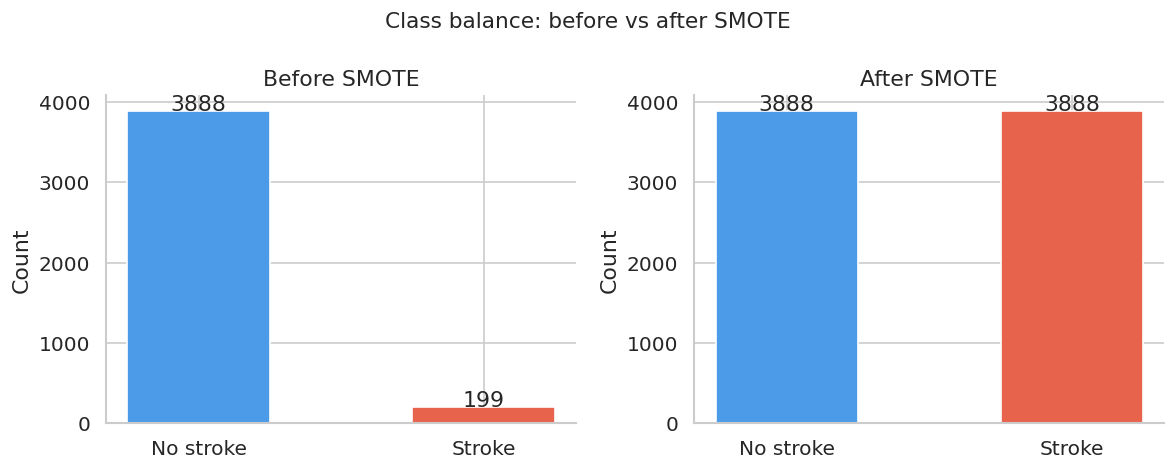

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4C9BE8', '#E8634C']

# Before
before = y_train.value_counts()
axes[0].bar(['No stroke', 'Stroke'], before.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 10, str(v), ha='center')

# After
after = pd.Series(y_train_sm).value_counts()
axes[1].bar(['No stroke', 'Stroke'], after.values, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 10, str(v), ha='center')

plt.suptitle('Class balance: before vs after SMOTE', fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'preprocessing_smote.png', bbox_inches='tight')
plt.show()

---
## 7. Save processed data

In [9]:
# Save train and test sets
X_train_sm_df = pd.DataFrame(X_train_sm, columns=X.columns)
y_train_sm_df = pd.Series(y_train_sm, name='stroke')

X_train_sm_df.to_csv(PROCESSED_PATH + 'X_train.csv', index=False)
y_train_sm_df.to_csv(PROCESSED_PATH + 'y_train.csv', index=False)
X_test.to_csv(PROCESSED_PATH + 'X_test.csv', index=False)
y_test.to_csv(PROCESSED_PATH + 'y_test.csv', index=False)

print('Saved to data/processed/:')
print(f'  X_train.csv  — {X_train_sm_df.shape[0]:,} rows (SMOTE applied)')
print(f'  y_train.csv  — {y_train_sm_df.shape[0]:,} rows')
print(f'  X_test.csv   — {X_test.shape[0]:,} rows (original, no SMOTE)')
print(f'  y_test.csv   — {y_test.shape[0]:,} rows')
print()
print('Saved to models/:')
print('  bmi_imputer.pkl')
print('  label_encoders.pkl')

Saved to data/processed/:
  X_train.csv  — 7,776 rows (SMOTE applied)
  y_train.csv  — 7,776 rows
  X_test.csv   — 1,022 rows (original, no SMOTE)
  y_test.csv   — 1,022 rows

Saved to models/:
  bmi_imputer.pkl
  label_encoders.pkl


---
## 8. Save preprocessing pipeline as `utils/preprocessing.py`

In [10]:
os.makedirs('../utils', exist_ok=True)

preprocessing_code = '''
"""
utils/preprocessing.py

Shared preprocessing logic used by both:
  - notebooks/03_model_training.ipynb  (training time)
  - app.py                             (prediction time)

This ensures the model always receives input in the exact
same format it was trained on.
"""
import numpy as np
import joblib
import os

MODELS_PATH = os.path.join(os.path.dirname(__file__), \'../models/\')

# Load saved encoders and imputer
encoders = joblib.load(MODELS_PATH + \'label_encoders.pkl\')
imputer  = joblib.load(MODELS_PATH + \'bmi_imputer.pkl\')

# Encoding maps (for reference and direct use in app.py)
GENDER_MAP        = {\'Male\': 1, \'Female\': 0}
MARRIED_MAP       = {\'Yes\': 1, \'No\': 0}
WORK_TYPE_MAP     = {\'Govt_job\': 0, \'Never_worked\': 1, \'Private\': 2,
                     \'Self-employed\': 3, \'children\': 4}
RESIDENCE_MAP     = {\'Rural\': 0, \'Urban\': 1}
SMOKING_MAP       = {\'Unknown\': 0, \'formerly smoked\': 1,
                     \'never smoked\': 2, \'smokes\': 3}


def preprocess_input(gender, age, hypertension, heart_disease,
                     ever_married, work_type, residence_type,
                     avg_glucose_level, bmi, smoking_status):
    """
    Accepts human-readable string/numeric inputs from the web form
    and returns a numpy array ready for model.predict_proba().

    Parameters
    ----------
    gender           : str  e.g. \'Male\' or \'Female\'
    age              : float
    hypertension     : int  0 or 1
    heart_disease    : int  0 or 1
    ever_married     : str  \'Yes\' or \'No\'
    work_type        : str  e.g. \'Private\'
    residence_type   : str  \'Urban\' or \'Rural\'
    avg_glucose_level: float
    bmi              : float or None
    smoking_status   : str  e.g. \'never smoked\'

    Returns
    -------
    np.ndarray of shape (1, 10)
    """
    features = np.array([[
        GENDER_MAP.get(gender, 0),
        float(age),
        int(hypertension),
        int(heart_disease),
        MARRIED_MAP.get(ever_married, 0),
        WORK_TYPE_MAP.get(work_type, 2),
        RESIDENCE_MAP.get(residence_type, 1),
        float(avg_glucose_level),
        float(bmi) if bmi else np.nan,
        SMOKING_MAP.get(smoking_status, 0),
    ]])

    # Impute BMI if missing
    features[:, 8] = imputer.transform(features[:, [8]]).ravel()

    return features
'''

with open('../utils/preprocessing.py', 'w') as f:
    f.write(preprocessing_code.strip())

# Create __init__.py so utils is importable as a package
with open('../utils/__init__.py', 'w') as f:
    f.write('')

print('Saved: utils/preprocessing.py')
print('Saved: utils/__init__.py')

Saved: utils/preprocessing.py
Saved: utils/__init__.py


---
## 9. Summary

In [11]:
print('=' * 55)
print('PREPROCESSING SUMMARY')
print('=' * 55)
print(f"""
Steps completed
  ✓ Dropped id column
  ✓ Removed 1 row with gender=Other
  ✓ Imputed {bmi_before} missing BMI values (median={bmi_median:.2f})
  ✓ Label-encoded 5 categorical columns
  ✓ 80/20 stratified train/test split
  ✓ Applied SMOTE to training set

Data saved to data/processed/
  X_train.csv  {X_train_sm_df.shape[0]:,} rows (post-SMOTE)
  y_train.csv  {y_train_sm_df.shape[0]:,} rows
  X_test.csv   {X_test.shape[0]:,} rows  (original distribution)
  y_test.csv   {y_test.shape[0]:,} rows

Artefacts saved to models/
  bmi_imputer.pkl
  label_encoders.pkl

Utils created
  utils/preprocessing.py  (shared by app.py + notebooks)

Ready for: 03_model_training.ipynb
""")
print('=' * 55)

PREPROCESSING SUMMARY

Steps completed
  ✓ Dropped id column
  ✓ Removed 1 row with gender=Other
  ✓ Imputed 201 missing BMI values (median=28.10)
  ✓ Label-encoded 5 categorical columns
  ✓ 80/20 stratified train/test split
  ✓ Applied SMOTE to training set

Data saved to data/processed/
  X_train.csv  7,776 rows (post-SMOTE)
  y_train.csv  7,776 rows
  X_test.csv   1,022 rows  (original distribution)
  y_test.csv   1,022 rows

Artefacts saved to models/
  bmi_imputer.pkl
  label_encoders.pkl

Utils created
  utils/preprocessing.py  (shared by app.py + notebooks)

Ready for: 03_model_training.ipynb

